## 3.3 主成分分析

<p style="text-indent:2em">主成分分析(Principal components analysis，以下简称PCA)是将多个变量化为少数几个主成分的一种统计方法，是最重要同时也是最常见的降维方法之一。下面将介绍其基本原理、基本流程以及如何通过Python实现主成分分析。

<center><img src='imgs/fig1.png' width=800 height=600 /></center>

### 3.3.1	主成分分析原理介绍

<p style="text-indent:2em">主成分分析的核心思想是通过线性变换将原始特征转换为一组互不相关的新特征（主成分），这些新特征按照方差大小排序，保留数据中最主要的变化模式。
    
<p style="text-indent:2em">假设数据矩阵$X$是$n×p$的，即：
    
<center><img src='imgs/fig2.png' width=400 height=500 /></center>

其中：$n$表示样本数（行数）, $p$表示特征数 / 维度（列数）。每个维度可以表示为$X_i$ (1 $\leq i \leq p$)。
    
<p style="text-indent:2em">我们希望找到一组新的变量 $F_1, F_2, ..., F_m$（$m \leq p$），满足：

$F_i$ 是 $X$ 的线性组合：
    
$$F_i = v_{i1}X_1 + v_{i2}X_2 + \cdots + v_{ip}X_p\tag{3-1}$$

$F_1$ 具有最大方差，$F_2$ 是与 $F_1$ 不相关(正交)的具有次大方差的变量，依此类推

$$Var(F_1) \geq Var(F_2) \geq \cdots \geq Var(F_m)\tag{3-2}$$
    
    

### 3.3.2	 主成分分析基本流程

主成分分析基本流程包括以下四步：
####  （1）数据预处理
<p style="text-indent:2em">原始数据往往具有不同的量纲与范围，直接对其应用PCA会导致方差被某些大尺度变量主导，进而影响主成分的选取。
    
<p style="text-indent:2em">数据变换公式如（3-3）所示：
$$x_{ij}^*={\frac{x_{ij}-\overline{x_j}}{s_j}} (i=1,2,…,n;j=1,2,..,p)\tag{3-3}$$
    
<p style="text-indent:2em">$\overline{x_j}$如（3-4）所示：

$$\overline{x_j}={\frac{1}{n}}∑_{i=1}^nx_{ij}\tag{3-4}$$


<p style="text-indent:2em">$s_j^2$如（3-5）所示：
$$s_j^2={\frac{1}{n-1}}∑_{i=1}^n(x_{ij}-\overline{x_j})^2\tag{3-5}$$ 	

#### (2)计算协方差矩阵
<p style="text-indent:2em">在降维方法中，如何判断哪些方向更重要是核心问题。统计学中，数据的方差被广泛用来衡量数据的变化范围与信息量。方差较大的方向说明数据点在该维度上变化剧烈，包含较多信息。相反，方差较小的方向意味着数据点在该维度上变化有限，信息较少，可能更多是噪声。主成分分析法的首要思想就是：选择数据方差最大的方向作为新坐标轴，这样能够保证映射后的低维表示尽量保留原始数据的差异性与结构特征。

<p style="text-indent:2em">为了量化变量间的相关性，PCA使用协方差矩阵。

<p style="text-indent:2em">计算样本数据的协方差矩阵公式：

$$Σ=(s_{ij})_{p×p}\tag{3-6}$$	
    
    
<p style="text-indent:2em">其中$s_{ij}$如（3-7）所示：


$$s_{ij}={\frac{1}{n-1}} ∑_{k=1}^n(x_{ki}-\overline{x_i})(x_{kj}-\overline{x_j})(i,j=1,2,…,p)\tag{3-7}$$
    
<p style="text-indent:2em">协方差矩阵是对称矩阵，且其对角线元素表示各变量的方差，非对角线元素表示变量间的协方差。

#### (3)  求解协方差矩阵的特征值$λ_i$及相应的正交化单位特征向量$v_i$

<p style="text-indent:2em">协方差矩阵的特征值分解为：
    $$Σv_i=λ_iv_i\tag{3-8}$$
其中，$v_i$是第$i$个单位特征向量，代表主成分的方向；$λ_i$是对应的特征值，代表第$i$个特征向量的方差。$λ_1$≥$λ_2$≥⋯≥$λ_m$>0。因此，PCA寻找的主成分就是特征向量，依照特征值大小排序，特征值最大的向量就是第一个主成分。所有特征向量相互正交。
<p style="text-indent:2em">第$i$个主成分$F_i$为： 
$$F_i=v_i^TX=v_{i1}X_1+v_{i2}X_2+...+v_{ip}X_p\tag{3-9}$$	

#### (4)	确定主成分的个数

<p style="text-indent:2em">$F_m$中的$m$代表主成分的个数，其个数是通过方差(信息)累计贡献率$G(m)$来最终确定的。
    
    
$$G(m)=∑_{i=1}^mλ_i / ∑_{k=1}^pλ_k\tag{3-10}$$ 	
<p style="text-indent:2em">累计贡献率用于判断保留多少主成分才算足够。通常阈值设置为90%或95%，即选择足够的主成分以涵盖原始数据90%-95%的变异。这一选择兼顾了降维带来的效率提升和信息完整性。

#### (5)	数据投影到主成分空间

<p style="text-indent:2em">选定主成分后，将原始数据投影到新坐标系：
$$Z_m=XV_m\tag{3-11}$$
    其中， $V_m=[v_1,v_2,...,v_m]$是由前$m$个特征向量组成的矩阵，$Z_m$是低维表示。此步骤将高维数据转换成低维表示，减少变量数量，方便后续分析。

### 3.3.3	 Python实现主成分分析

<p style="text-indent:2em">接下来我们将基于Python分步演示上述主成分分析流程以实现降维。
    
- 具体步骤：
    - 导入数据集
    - 数据标准化
    - 计算数据集协方差矩阵
    - 求解协方差矩阵的特征值及相应的正交化单位特征向量
    - 将特征值和特征向量对应
    - 确定主成分的个数
    - 组合特征向量实现降维
    - 可视化降维后的数据分布
    
    
    
- 数据集来源：Kaggle数据库。


- 数据集情况：
    
    - 8个医学变量（维度）
        - Pregnancies（马印第安女性的怀孕数）
        - Glucose（血糖）
        - BloodPressure（血压）
        - SkinThickness（肱三头肌皮肤皱皱厚度）
        - Insulin（胰岛素水平）
        - BMI
        - Age（年龄）
        
    - 1个目标变量   
        - Outcome（皮马印第安女性是否患有糖尿病）

#### (1) 导入数据，并展示数据特征

<p style="text-indent:2em">对数据特征进行数据可视化，可以对数据的八个特征与患者之间的关系有初步的了解。示例代码如下：

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('./data/diabetes.csv')  #导入csv格式的糖尿病患者数据
df.head()           #只输出前几行数据

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


<p style="text-indent:2em">由运行结果可知，前八项是用于PCA的相关性指标，Outcome用于验证主成分分析是否达到了降维的目的，Outcome中YES表示样本为糖尿病患者，NO表示样本并非糖尿病患者。
<p style="text-indent:2em">数据可视化可以更直观地观察原始数据以展示数据特征，数据可视化的示例代码如下：

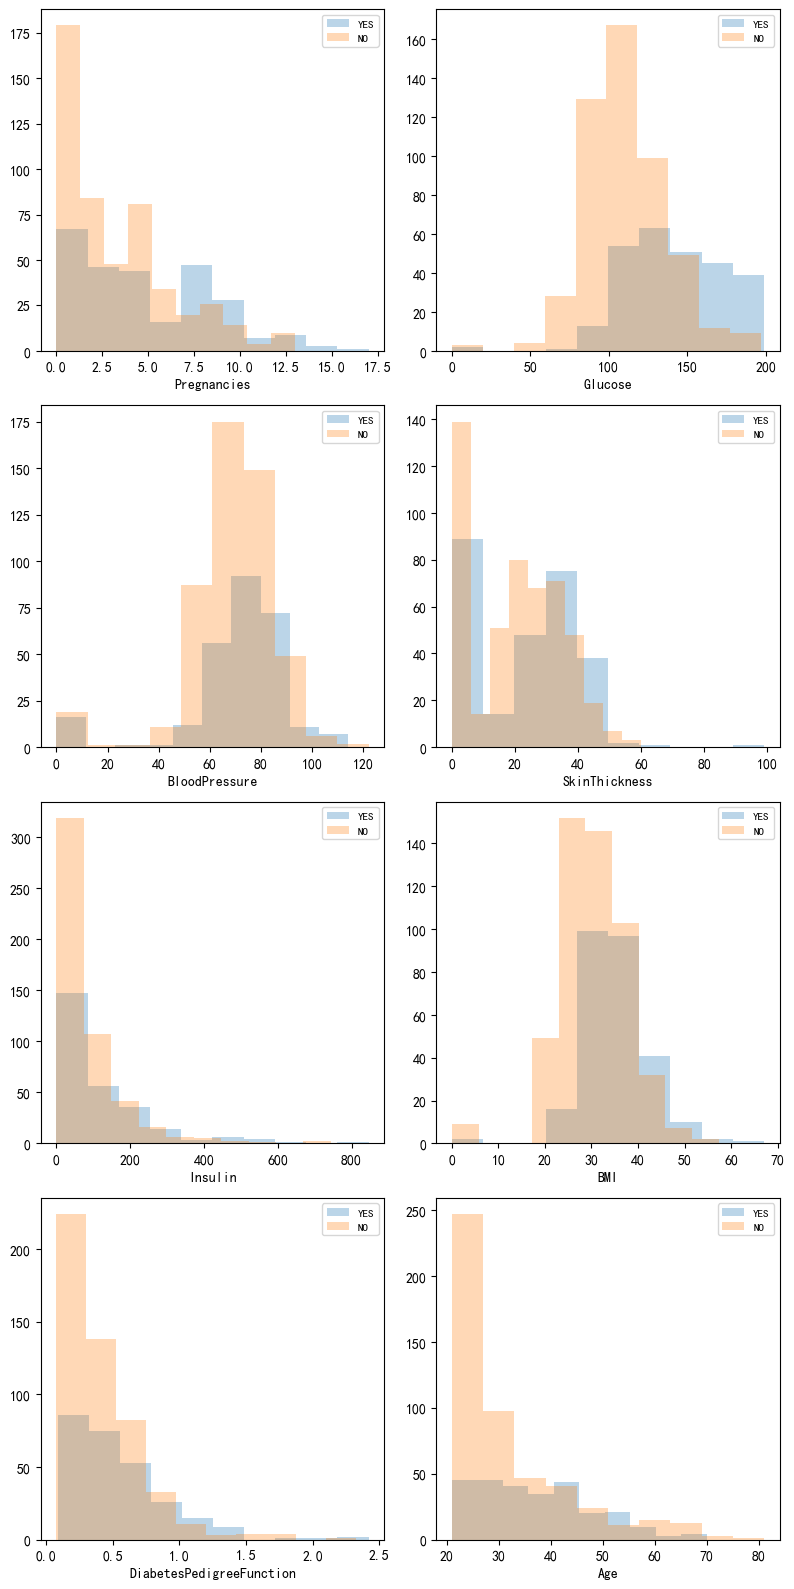

In [32]:
X = df.iloc[:,0:8].values                              #将数据分成特征和标签，X为特征
y = df.iloc[:,8].values                                #y标签

import matplotlib.pyplot as plt
label_dic = {1:'YES',2:'NO'}                           #设置标签
feature_dict = {0:'Pregnancies',1:'Glucose',2:'BloodPressure',3:'SkinThickness',
                4:'Insulin',5:'BMI',6:'DiabetesPedigreeFunction',7:'Age'} #设置数据特征
plt.figure(figsize = (8,16))                           #设置绘图区域的大小
for cnt in range(8):
    plt.subplot(4,2,cnt+1)                             #用4X2的子图来展示数据的特征
    for lab in ('YES','NO'):
        plt.hist(X[y == lab,cnt],label = lab,bins = 10,alpha = 0.3,)
    plt.xlabel(feature_dict[cnt])
    plt.legend(loc = 'upper right',fancybox = True,fontsize = 8)
plt.tight_layout()
plt.show()

<p style="text-indent:2em">由图可以看出，几乎所有的特征的单独区别能力都较弱，部分特征数据样本混杂在一起。这证明原始的所有指标均不能独立地将非糖尿病人与糖尿病人区分开来。

#### (2) 标准化处理数据

<p style="text-indent:2em">一般情况下，在利用真实数据集前，需对数据集进行标准化处理，本例子使用Sklearn库中的StandardScaler方法对数据进行标准化处理。示例代码如下：

In [4]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

#### (3) 计算数据集的协方差矩阵

<p style="text-indent:2em">根据公式（3-6）计算协方差矩阵（$8×8$矩阵），示例代码如下：

In [5]:
mean_vec = np.mean(X_std,axis = 0)                       #对各列求均值
cov_mat = (X_std - mean_vec).T.dot((X_std - mean_vec))/(X_std.shape[0] - 1) #协方差公式
print('协方差矩阵：\n%s' %cov_mat)

协方差矩阵：
[[ 1.00130378  0.12962746  0.14146618 -0.08177826 -0.07363049  0.01770615
  -0.03356638  0.54505093]
 [ 0.12962746  1.00130378  0.15278853  0.05740263  0.33178913  0.2213593
   0.13751636  0.26385788]
 [ 0.14146618  0.15278853  1.00130378  0.2076409   0.08904933  0.2821727
   0.04131875  0.23984024]
 [-0.08177826  0.05740263  0.2076409   1.00130378  0.43735204  0.39308503
   0.18416737 -0.11411885]
 [-0.07363049  0.33178913  0.08904933  0.43735204  1.00130378  0.19811702
   0.18531222 -0.04221793]
 [ 0.01770615  0.2213593   0.2821727   0.39308503  0.19811702  1.00130378
   0.14083033  0.03628912]
 [-0.03356638  0.13751636  0.04131875  0.18416737  0.18531222  0.14083033
   1.00130378  0.03360507]
 [ 0.54505093  0.26385788  0.23984024 -0.11411885 -0.04221793  0.03628912
   0.03360507  1.00130378]]


<p style="text-indent:2em">除了根据公式计算数据集的协方差外，还可以通过直接调用Numpy工具包计算协方差矩阵，示例代码如下：

In [6]:
print('numpy计算协方差矩阵:\n',np.cov(X_std.T))

numpy计算协方差矩阵:
 [[ 1.00130378  0.12962746  0.14146618 -0.08177826 -0.07363049  0.01770615
  -0.03356638  0.54505093]
 [ 0.12962746  1.00130378  0.15278853  0.05740263  0.33178913  0.2213593
   0.13751636  0.26385788]
 [ 0.14146618  0.15278853  1.00130378  0.2076409   0.08904933  0.2821727
   0.04131875  0.23984024]
 [-0.08177826  0.05740263  0.2076409   1.00130378  0.43735204  0.39308503
   0.18416737 -0.11411885]
 [-0.07363049  0.33178913  0.08904933  0.43735204  1.00130378  0.19811702
   0.18531222 -0.04221793]
 [ 0.01770615  0.2213593   0.2821727   0.39308503  0.19811702  1.00130378
   0.14083033  0.03628912]
 [-0.03356638  0.13751636  0.04131875  0.18416737  0.18531222  0.14083033
   1.00130378  0.03360507]
 [ 0.54505093  0.26385788  0.23984024 -0.11411885 -0.04221793  0.03628912
   0.03360507  1.00130378]]


<p style="text-indent:2em">事实上，直接调用Numpy工具包计算协方差矩阵代码更为简洁，方便使用。

#### (4) 求解协方差矩阵的特征值及相应的正交化单位特征向量

单位特征向量是指在特征值分解中，长度为1的特征向量。

示例代码如下：

In [7]:
eig_vals,eig_vecs = np.linalg.eig(cov_mat)
print('特征值:\n%s'%eig_vals)
print('单位特征向量:\n%s'%eig_vecs)

特征值:
[2.09711056 1.73346726 0.42036353 0.40498938 0.68351839 0.76333832
 0.87667054 1.03097228]
单位特征向量:
[[-0.1284321  -0.59378583 -0.58879003  0.11784098 -0.19359817  0.47560573
  -0.08069115  0.01308692]
 [-0.39308257 -0.17402908 -0.06015291  0.45035526 -0.09416176 -0.46632804
   0.40432871 -0.46792282]
 [-0.36000261 -0.18389207 -0.19211793 -0.01129554  0.6341159  -0.32795306
  -0.05598649  0.53549442]
 [-0.43982428  0.33196534  0.28221253  0.5662838  -0.00958944  0.48786206
  -0.03797608  0.2376738 ]
 [-0.43502617  0.25078106 -0.13200992 -0.54862138  0.27065061  0.34693481
   0.34994376 -0.33670893]
 [-0.45194134  0.1009598  -0.03536644 -0.34151764 -0.68537218 -0.25320376
  -0.05364595  0.36186463]
 [-0.27061144  0.122069   -0.08609107 -0.00825873  0.08578409 -0.11981049
  -0.8336801  -0.43318905]
 [-0.19802707 -0.62058853  0.71208542 -0.21166198  0.03335717  0.10928996
  -0.0712006  -0.07524755]]


#### (5) 将特征值和特征向量对应起来，按照特征值大小排序
示例代码如下：

In [8]:
#对应特征值和特征向量
eig_pairs = [(np.abs(eig_vals[i]),eig_vecs[:,i])for i in range(len(eig_vals))] 
print('特征值和特征向量：\n',eig_pairs)
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
eig_pairs.sort(key=lambda x:x[0],reverse=True)  #排序后的特征值和特征向量对
print('特征值由大到小排序结果:')
for i in eig_pairs:
    print(i[0])

特征值和特征向量：
 [(2.097110557994529, array([-0.1284321 , -0.39308257, -0.36000261, -0.43982428, -0.43502617,
       -0.45194134, -0.27061144, -0.19802707])), (1.7334672594471254, array([-0.59378583, -0.17402908, -0.18389207,  0.33196534,  0.25078106,
        0.1009598 ,  0.122069  , -0.62058853])), (0.42036352804956717, array([-0.58879003, -0.06015291, -0.19211793,  0.28221253, -0.13200992,
       -0.03536644, -0.08609107,  0.71208542])), (0.40498937781489863, array([ 0.11784098,  0.45035526, -0.01129554,  0.5662838 , -0.54862138,
       -0.34151764, -0.00825873, -0.21166198])), (0.6835183858447283, array([-0.19359817, -0.09416176,  0.6341159 , -0.00958944,  0.27065061,
       -0.68537218,  0.08578409,  0.03335717])), (0.7633383156496736, array([ 0.47560573, -0.46632804, -0.32795306,  0.48786206,  0.34693481,
       -0.25320376, -0.11981049,  0.10928996])), (0.8766705419094796, array([-0.08069115,  0.40432871, -0.05598649, -0.03797608,  0.34994376,
       -0.05364595, -0.8336801 , -0.071200

<p style="text-indent:2em">由输出结果可知，有三个主成分的特征值大于1。但$m$的最终选择还需要考虑累积贡献率。

#### (6) 确定主成分的个数

<p style="text-indent:2em">计算累积贡献率，将特征向量累积至一定百分比时，就选择其为降维后的维度$m$。示例代码如下：

In [30]:
total = sum(eig_vals)                                                 #特征值求和
var_exp = [(i/total)*100 for i in sorted(eig_vals,reverse = True)]    #贡献率
print('贡献率：\n',var_exp)
cum_var_exp = np.cumsum(var_exp)
print('累积贡献率：\n',cum_var_exp)      #累积贡献率

贡献率：
 [26.179749316110083, 21.640126757746504, 12.870373364801907, 10.944113047600435, 9.529304819389642, 8.532854849331162, 5.247702246321907, 5.05577559869836]
累积贡献率：
 [ 26.17974932  47.81987607  60.69024944  71.63436249  81.16366731
  89.69652215  94.9442244  100.        ]


<p style="text-indent:2em">由输出结果可知，前5个主成分使累积贡献率超过了80%(81.16366731)，前6个主成分使得累积贡献率接近90%(89.69652215)。关于累计贡献率的选取标准，可以根据自身需求进行选择。结合上述特征值的大小，为了更有效地降维，此处选取$m$=6，即选择前6个主成分分析，降至6维。

#### (7) 组合特征向量实现降维
示例代码如下：

In [31]:
V = np.hstack((eig_pairs[0][1].reshape(8,1),    
               eig_pairs[1][1].reshape(8,1),
               eig_pairs[2][1].reshape(8,1),
               eig_pairs[3][1].reshape(8,1),
               eig_pairs[4][1].reshape(8,1),
               eig_pairs[5][1].reshape(8,1)))     #由前6个特征向量组成的矩阵V
Z = X_std.dot(V)   #降维后的矩阵Z
print('PCA降维:\n',Z)

PCA降维:
 [[-1.06850273 -1.23489499 -0.09592984 -0.4969902   0.10998491 -0.35718251]
 [ 1.12168331  0.73385167  0.71293816 -0.28505622  0.38950719  0.40632934]
 [ 0.39647671 -1.59587594 -1.76067844  0.07039464 -0.90647385  0.04001752]
 ...
 [ 0.28347525 -0.09706503  0.07719194  0.68756106  0.52300926  0.53826993]
 [ 1.06032431 -0.83706234 -0.42503045  0.20449292 -0.95759303 -0.15330712]
 [ 0.83989172  1.15175485  1.00917817 -0.0869288   0.08265082  0.15009639]]


<p style="text-indent:2em">由输出结果可知，使用PCA降维技术可以把原数据矩阵从768x8降到768x6。

####  (8) 可视化降维后的数据分布

<p style="text-indent:2em">利用可视化直观评价主成分分析方法，案例数据有8个特征，最终选择6个主成分。由于通过可视化无法显示6个主成分，因此只使用两维平面图和三维立体图分别展示PCA降维后的情况。示例代码如下：

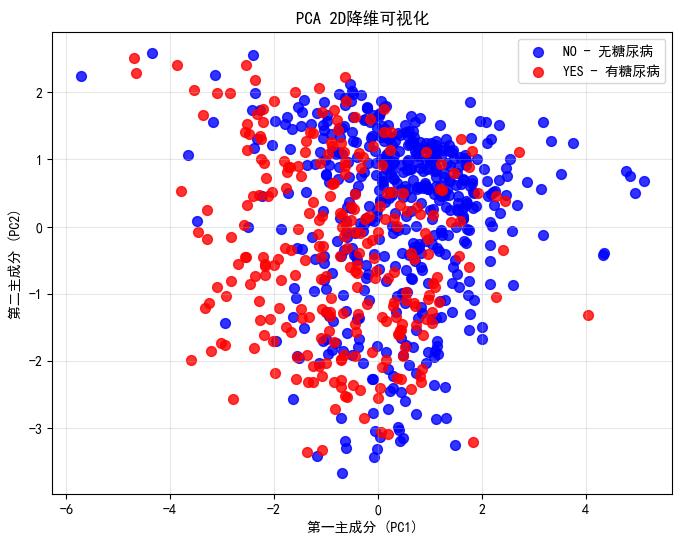

In [33]:

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号


# 将字符串标签转换为数值
y_numeric = np.where(y == 'YES', 1, 0)

# 创建掩码
no_mask = (y_numeric == 0)
yes_mask = (y_numeric == 1)

# 简洁2D图
plt.figure(figsize=(8, 6))
plt.scatter(Z[no_mask, 0], Z[no_mask, 1], 
           c='blue', label='NO - 无糖尿病', alpha=0.8, s=50)
plt.scatter(Z[yes_mask, 0], Z[yes_mask, 1], 
           c='red', label='YES - 有糖尿病', alpha=0.8, s=50)

plt.xlabel('第一主成分 (PC1)')
plt.ylabel('第二主成分 (PC2)')
plt.title('PCA 2D降维可视化')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<p style="text-indent:2em">三维图展示第一、二、三主成分，示例代码如下：

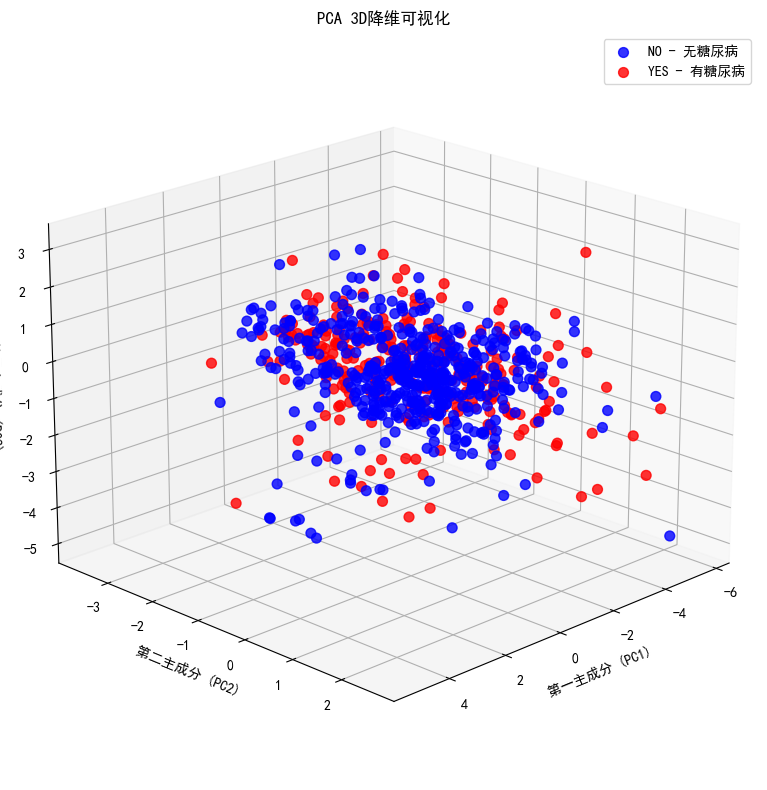

In [34]:
from mpl_toolkits.mplot3d import Axes3D

# 简洁3D图
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')  # 创建3D坐标轴

ax.scatter(Z[no_mask, 0], Z[no_mask, 1], Z[no_mask, 2], 
          c='blue', label='NO - 无糖尿病', alpha=0.8, s=50)
ax.scatter(Z[yes_mask, 0], Z[yes_mask, 1], Z[yes_mask, 2], 
          c='red', label='YES - 有糖尿病', alpha=0.8, s=50)

ax.set_xlabel('第一主成分 (PC1)')
ax.set_ylabel('第二主成分 (PC2)')
ax.set_zlabel('第三主成分 (PC3)')
ax.set_title('PCA 3D降维可视化')
ax.legend()

# 调整视角以便更好地看到Z轴标签
ax.view_init(elev=20, azim=45)  # 调整仰角和方位角
plt.tight_layout()
plt.show()